In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [44]:
top_genes = [
    "CD74",
    "HLA-DPB1",
    "HLA-DRB1",
    "HLA-DMA",
    "HLA-DMB",
    "HLA-DRA",
    "HLA-DPA1",
    "HLA-DOA",
    "HLA-E",
    "HLA-DQA1",
    "PTPRC",
    "LYN",
    "IL10",
    "CD3E",
    "FCGR3A",
    "LCK",
    "CASP1",
    "CD2",
    "B2M",
    "LCP2",
    "SERPING1",
    "CD4",
    "FCER1G",
    "C1QB",
    "C1QC",
    "RUNX1",
    "HLA-C",
    "SYK",
    "TIMP1",
    "CD44",
    "MMP14",
    "IL7R",
    "COL1A2",
    "ISG15",
    "IFI44L",
    "RSAD2",
    "MAOB",
    "CASP4",
    "CCR5",
    "CASP8",
    "CTSS",
    "CCL5",
    "DAPP1",
    "HLA-B",
    "ITGB2",
    "ITGA5",
    "PLCG2",
    "TYROBP",
    "ALOX5",
    "LSP1",
    "GZMA",
    "HLA-DQB1",
    "CCR2",
    "CYBA",
    "NCF1",
    "CLEC7A",
    "PTGS1",
    "RIPK3",
    "IL2RB",
    "PYGL",
    "CD53",
    "RUNX3",
    "GZMK",
    "LAPTM5",
    "SPI1",
    "ICAM1",
    "CD3D",
    "CD86",
    "HAVCR2",
    "ALPK1",
    "PTPN22",
    "TIFA",
    "CXCR3",
    "PTPN6",
    "CCR1",
    "C1S",
    "C2",
    "HCK",
    "VAV1",
    "ITGB3",
    "PIK3R5",
    "HLA-DQA2",
    "RNASE2",
    "BTK",
    "ITGB7",
    "LILRB2",
    "ANG",
    "HCST",
    "FCGR2B",
    "PIK3R6",
    "ITK",
    "TLR7",
    "PRF1",
    "GZMH",
    "TLR3",
    "IFIH1",
    "HERC5",
    "COL1A1",
    "CD80",
    "CD163",
]

In [45]:
path_rppa = 'data/Human__TCGA_LGG__MDA__RPPA__MDA_RPPA__01_28_2016__BI__Gene__Firehose_RPPA.cct.txt'
path_mutation = 'data/Human__TCGA_LGG__WUSM__Mutation__GAIIx__01_28_2016__BI__Gene__Firehose_MutSig2CV.cbt.txt'

path_scna_gen = 'data/Human__TCGA_LGG__BI__SCNA__SNP_6.0__01_28_2016__BI__Gene__Firehose_GISTIC2.cct'

rppa = pd.read_csv(path_rppa, sep='\t', index_col=0)
muta = pd.read_csv(path_mutation, sep='\t', index_col=0)
scna_gen = pd.read_csv(path_scna_gen, sep='\t', index_col=0)

print(f"Dimensión datos rppa: {rppa.shape}")  # espera genes x muestras
print(f"Dimensión datos mutaciones: {muta.shape}")
print(f"Dimensión datos scna: {scna_gen.shape}")

Dimensión datos rppa: (148, 429)
Dimensión datos mutaciones: (889, 513)
Dimensión datos scna: (24776, 513)


In [46]:
rppa = rppa.loc[rppa.index.isin(top_genes)]
scna_gen = scna_gen.loc[scna_gen.index.isin(top_genes)]
muta = muta.loc[muta.index.isin(top_genes)]

print(f"Dimensión datos rppa: {rppa.shape}")  # espera genes x muestras
print(f"Dimensión datos mutaciones: {muta.shape}")
print(f"Dimensión datos scna: {scna_gen.shape}")

Dimensión datos rppa: (2, 429)
Dimensión datos mutaciones: (6, 513)
Dimensión datos scna: (86, 513)


In [47]:
rppa.head()

,TCGA.CS.4938,TCGA.CS.4942,TCGA.CS.4943,TCGA.CS.4944,TCGA.CS.5390,TCGA.CS.5393,TCGA.CS.5394,TCGA.CS.5396,TCGA.CS.5397,TCGA.CS.6186,...,TCGA.VM.A8CD,TCGA.VM.A8CE,TCGA.VM.A8CH,TCGA.VV.A829,TCGA.VV.A86M,TCGA.VW.A7QS,TCGA.W9.A837,TCGA.WY.A85B,TCGA.WY.A85C,TCGA.WY.A85D
attrib_name,,,,,,,,,,,,,,,,,,,,,
LCK,-0.4443,-0.1088,0.7381,-0.7745,-0.0495,-1.1505,-0.2256,-0.1528,-0.6895,-0.3404,...,0.2258,0.0003,-0.1185,0.0049,-0.7589,0.0736,-0.2813,-0.2848,-0.5002,-0.5403
SYK,0.4032,-0.2015,0.1592,0.2076,-0.0816,0.5148,-1.3236,-0.6708,0.1094,0.6683,...,-0.0028,0.5503,0.0555,0.9069,-0.1382,-0.8861,0.4512,0.5085,-0.1375,0.1182


In [48]:
muta.head()

,TCGA.FG.A711,TCGA.DU.6392,TCGA.HT.7873,TCGA.QH.A6XC,TCGA.DB.A4XH,TCGA.DH.A7UU,TCGA.HT.A5R9,TCGA.HW.8322,TCGA.E1.A7YN,TCGA.FG.6692,...,TCGA.S9.A7R4,TCGA.DB.A4X9,TCGA.DU.7018,TCGA.VM.A8CE,TCGA.CS.4944,TCGA.HW.7486,TCGA.VV.A86M,TCGA.HT.8558,TCGA.HT.8019,TCGA.FG.8181
attrib_name,,,,,,,,,,,,,,,,,,,,,
ALPK1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
C2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
CASP1,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
CD163,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
CD44,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [49]:
scna_gen.head()

,TCGA.CS.4938,TCGA.CS.4941,TCGA.CS.4942,TCGA.CS.4943,TCGA.CS.4944,TCGA.CS.5390,TCGA.CS.5393,TCGA.CS.5394,TCGA.CS.5395,TCGA.CS.5396,...,TCGA.VW.A8FI,TCGA.W9.A837,TCGA.WH.A86K,TCGA.WY.A858,TCGA.WY.A859,TCGA.WY.A85A,TCGA.WY.A85B,TCGA.WY.A85C,TCGA.WY.A85D,TCGA.WY.A85E
attrib_name,,,,,,,,,,,,,,,,,,,,,
ISG15,0.004,0.459,0.002,-0.043,-0.009,-0.801,0.007,-0.860,-0.061,-0.834,...,0.030,-0.785,0.014,0.005,-0.02,-0.008,-0.028,0.015,0.021,0.052
C1QC,0.004,0.459,0.002,-0.043,-0.009,-0.771,0.007,-0.830,-0.061,-0.836,...,3.434,-0.805,0.014,0.005,-0.02,-0.008,-0.009,0.015,0.021,0.052
C1QB,0.004,0.459,0.002,-0.043,-0.009,-0.771,0.007,-0.830,-0.061,-0.836,...,3.434,-0.805,0.014,0.005,-0.02,-0.008,-0.009,0.015,0.021,0.052
RUNX3,0.004,0.459,0.002,-0.043,-0.009,-0.771,0.007,-0.830,-0.061,-0.836,...,-0.001,-0.805,0.014,0.005,-0.02,-0.008,-0.009,0.015,0.021,0.052
LAPTM5,0.004,0.459,0.002,-0.043,-0.009,-0.771,0.007,-0.834,-0.061,-0.836,...,-0.001,-0.805,0.014,0.005,-0.02,-0.008,-0.009,0.015,0.021,0.052


El SCNA muestra:

Es un valor continuo de logaritmo en base 2 (log2 ratio) que indica el cambio en el número de copias relativo al genoma de referencia.

Valores positivos indican ganancias o amplificaciones (más copias que lo normal).

Valores negativos indican pérdidas o deleciones (menos copias).

Este valor puede usarse para cuantificar la magnitud del cambio en copias.

In [50]:
scna_gen = scna_gen.T 
scna_gen.head()

attrib_name,ISG15,C1QC,C1QB,RUNX3,LAPTM5,LCK,IFI44L,CD53,PTPN22,CD2,...,LILRB2,HCK,RUNX1,ITGB2,IL2RB,TLR7,MAOB,TIMP1,CXCR3,BTK
TCGA.CS.4938,0.004,0.004,0.004,0.004,0.004,0.004,0.004,0.003,0.003,0.003,...,0.008,-0.007,0.005,0.005,0.011,-0.206,-0.206,-0.206,0.123,0.123
TCGA.CS.4941,0.459,0.459,0.459,0.459,0.459,0.459,0.447,0.447,0.447,0.447,...,0.021,0.021,0.022,0.022,0.029,0.012,0.000,0.000,0.000,0.000
TCGA.CS.4942,0.002,0.002,0.002,0.002,0.002,0.002,0.002,0.002,0.002,0.002,...,-0.715,0.019,-0.006,-0.006,0.025,0.016,0.016,0.016,0.016,0.016
TCGA.CS.4943,-0.043,-0.043,-0.043,-0.043,-0.043,-0.043,-0.043,-0.043,-0.043,-0.043,...,-0.276,-0.022,-0.106,-0.106,-0.870,-0.084,-0.084,-0.084,-0.084,-0.084
TCGA.CS.4944,-0.009,-0.009,-0.009,-0.009,-0.009,-0.009,-0.009,-0.677,-0.677,-0.691,...,-0.674,-0.027,-0.002,-0.002,-0.027,-0.048,-0.048,-0.048,-0.048,-0.048


In [51]:
data_cox = pd.read_csv('data/data_cox_with_survival3yr.csv', index_col=0)
data_cox.head()

,CD74,HLA-DPB1,HLA-DRB1,HLA-DMA,HLA-DMB,HLA-DRA,HLA-DPA1,HLA-DOA,HLA-E,HLA-DQA1,...,TLR3,IFIH1,HERC5,COL1A1,CD80,CD163,overall_survival,status,risk_score,survival_3yr
TCGA.CS.4938,12.5668,8.6102,8.7590,8.5993,8.9834,10.7880,8.8908,6.8782,12.2597,6.8204,...,6.0359,7.7536,9.1736,5.7512,0.5055,6.8627,3574.0,False,-7.832610,1
TCGA.CS.4941,15.4927,11.9222,12.3668,10.5364,10.8081,13.9021,12.5162,10.0694,13.9244,10.2799,...,8.3274,10.1575,10.4911,8.4117,3.8538,9.7537,234.0,True,-2.580570,0
TCGA.CS.4942,15.3739,11.4483,12.7477,10.5580,10.8706,13.7942,11.9650,10.3466,13.7275,10.4735,...,9.0234,9.1324,9.3929,5.8167,2.9856,8.9766,1335.0,True,-3.892725,1
TCGA.CS.4943,13.2865,10.4928,9.8587,9.0924,9.5139,11.8657,10.5019,8.5010,11.6388,8.4154,...,5.8916,7.0874,6.7673,8.6443,1.7148,8.7332,1106.0,True,-6.731689,1
TCGA.CS.4944,14.4549,11.6700,11.6364,10.3967,9.8603,13.2601,11.5003,9.0541,12.5336,9.8875,...,6.3961,7.6706,8.1443,4.6267,0.0000,9.8959,1828.0,False,-4.565826,1


In [52]:
import pandas as pd

# Renombrar columnas de scna_gen para indicar origen "_scna"
scna_renamed = scna_gen.add_suffix('_scna')

# Renombrar columnas de data_cox para indicar origen "_expression"
cox_renamed = data_cox.add_suffix('_expression')

# Mantener la columna survival_3yr sin sufijo, directamente desde data_cox
survival_col = data_cox['survival_3yr']

# Encontrar genes comunes basados en nombres base sin sufijo
genes_cox = set([col.replace('_expression', '') for col in cox_renamed.columns])
genes_scna = set([col.replace('_scna', '') for col in scna_renamed.columns])
common_genes = genes_cox.intersection(genes_scna)

# Columnas para filtrar
cols_cox_common = [gene + '_expression' for gene in common_genes]
cols_scna_common = [gene + '_scna' for gene in common_genes]

# Filtrado de columnas para genes comunes
cox_filtered = cox_renamed[cols_cox_common]
scna_filtered = scna_renamed[cols_scna_common]

# Unir los datos por índice (muestras)
merged_data = pd.merge(cox_filtered, scna_filtered, left_index=True, right_index=True, how='inner')

# Añadir la columna survival_3yr de data_cox (sin sufijo)
merged_data = merged_data.join(survival_col, how='inner')

# Ordenar columnas para que cada gen tenga expresión y SCNA lado a lado
ordered_cols = []
for gene in sorted(common_genes):
    ordered_cols.append(gene + '_expression')
    ordered_cols.append(gene + '_scna')
ordered_cols.append('survival_3yr')

merged_data = merged_data[ordered_cols]

merged_data.head()



,ALOX5_expression,ALOX5_scna,ALPK1_expression,ALPK1_scna,ANG_expression,ANG_scna,B2M_expression,B2M_scna,BTK_expression,BTK_scna,...,TIMP1_scna,TLR3_expression,TLR3_scna,TLR7_expression,TLR7_scna,TYROBP_expression,TYROBP_scna,VAV1_expression,VAV1_scna,survival_3yr
TCGA.CS.4938,6.7825,0.002,6.1764,-0.004,4.2172,0.003,14.0208,0.007,7.5587,0.123,...,-0.206,6.0359,-0.004,8.7836,-0.206,10.0914,0.008,8.1719,0.008,1
TCGA.CS.4941,8.8312,-0.584,7.3835,-0.017,5.6640,-0.601,15.7253,-0.027,8.4563,0.000,...,0.000,8.3274,-0.017,9.1601,0.012,10.9623,0.021,8.4262,0.021,0
TCGA.CS.4942,8.3817,-0.004,7.5130,-0.021,5.4590,0.021,15.6693,0.004,9.0002,0.016,...,0.016,9.0234,-0.021,9.2543,0.016,10.8639,0.020,8.6412,0.020,1
TCGA.CS.4943,7.7779,0.024,5.7414,-0.859,3.8007,0.008,13.6961,0.056,7.4972,-0.084,...,-0.084,5.8916,-0.872,8.4801,-0.084,9.9841,-0.276,7.6479,-0.041,1
TCGA.CS.4944,7.0946,-0.003,7.3343,0.017,6.4809,0.004,14.4556,-0.011,7.0513,-0.048,...,-0.048,6.3961,0.017,7.8453,-0.048,10.3048,0.609,7.3253,-0.015,1


## Modelos

In [53]:
# Librerías para datos y gráficos
import numpy as np          # Para trabajar con arreglos numéricos
import pandas as pd         # Para manejar tablas de datos (DataFrames)
import matplotlib.pyplot as plt  # Para hacer gráficos

# Para manejar fechas y el sistema operativo
import datetime             # Para trabajar con fechas y horas
import os                   # Para funciones de archivos y carpetas

# Herramientas de machine learning (scikit-learn)
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV  # Dividir datos, validación y búsqueda de parámetros
from sklearn.preprocessing import StandardScaler                                  # Escalar datos
from sklearn.pipeline import Pipeline                                            # Encadenar pasos de datos y modelos
from sklearn.metrics import roc_auc_score, roc_curve, auc                       # Medir calidad de los modelos
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier  # Modelos de árboles
from sklearn.linear_model import LogisticRegression                             # Modelo de regresión

# Para análisis de supervivencia
from lifelines import KaplanMeierFitter                                       # Para crear curvas de supervivencia
from lifelines.statistics import logrank_test                                 # Prueba para comparar curvas
from sksurv.ensemble import RandomSurvivalForest                              # Modelo de bosque para supervivencia
from sksurv.util import Surv                                                   # Formato de datos para supervivencia
from sksurv.metrics import concordance_index_censored                        # Medida para evaluar modelos de supervivencia

# Para redes neuronales con TensorFlow/Keras
import tensorflow as tf                                                        # Framework de deep learning
from tensorflow.keras.models import Sequential                               # Modelo básico en capas
from tensorflow.keras.layers import Dense, Dropout                          # Capas para red neuronal
from tensorflow.keras.optimizers import Adam                                # Algoritmo para entrenar la red
from tensorflow.keras.callbacks import EarlyStopping, TensorBoard          # Para controlar y monitorear el entrenamiento

# Para balancear datos y generar muestras nuevas
from imblearn.over_sampling import SMOTE                                   # Para balancear datos desbalanceados
from ctgan import CTGAN                                                    # Para crear datos sintéticos

# Para usar XGBoost, un modelo potente basado en árboles
import xgboost as xgb          

In [54]:
# Función para evaluar modelo y obtener AUC
def evaluar_modelo(modelo, X, y, cv):
    auc_scores = []
    for train_idx, test_idx in cv.split(X, y):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        modelo.fit(X_train, y_train)
        y_proba = modelo.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_proba)
        auc_scores.append(auc)

    return auc_scores, y_test, y_proba

In [55]:
# Extraer todas las columnas excepto 'survival_3yr' para X
X = merged_data.drop(columns=['survival_3yr']).values

# Variable objetivo
y = merged_data['survival_3yr'].values


In [56]:
# Definir el modelo Random Forest básico
rf = RandomForestClassifier(random_state=42)

# Definir el grid de hiperparámetros que quieres probar
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [8, 10, 12, None],
    'max_features': [0.3, 0.5, 'sqrt'],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Configurar validación cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Configurar GridSearch
grid_search = GridSearchCV(rf, param_grid, cv=cv, scoring='roc_auc', n_jobs=-1)

# Ajustar modelo
grid_search.fit(X, y)

# Mejores hiperparámetros encontrados
print("Mejores hiperparámetros:", grid_search.best_params_)
print("Mejor AUC ROC:", grid_search.best_score_)


Mejores hiperparámetros: {'max_depth': 8, 'max_features': 0.5, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 300}
Mejor AUC ROC: 0.6432543036600495


AUC ROC promedio Random Forest para supervivencia a 3 años: 0.6433 ± 0.0266


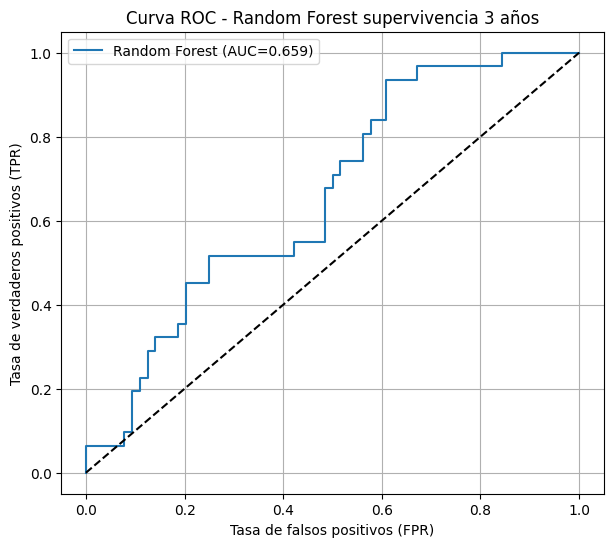

In [63]:
# Definir Random Forest con parámetros ajustados
rf = RandomForestClassifier(n_estimators=300, random_state=42, min_samples_split=10, min_samples_leaf=4, max_features=0.5, max_depth=8, bootstrap=True)

# Validación cruzada estratificada 5 pliegues
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Evaluacion
auc_scores, y_test, y_proba = evaluar_modelo(rf, X, y, cv)
print(f"AUC ROC promedio Random Forest para supervivencia a 3 años: {np.mean(auc_scores):.4f} ± {np.std(auc_scores):.4f}")

# Grafica ROC para primer fold
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f'Random Forest (AUC={auc_scores[-1]:.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('Tasa de falsos positivos (FPR)')
plt.ylabel('Tasa de verdaderos positivos (TPR)')
plt.title('Curva ROC - Random Forest supervivencia 3 años')
plt.legend()
plt.grid(True)
plt.show()

In [58]:
xgb_clf = xgb.XGBClassifier(eval_metric='logloss', use_label_encoder=False, random_state=42)

param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [4, 6, 10],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.5]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(xgb_clf, param_grid, cv=cv, scoring='roc_auc', n_jobs=-1)

grid_search.fit(X, y)

print("Mejores hiperparámetros XGBoost:", grid_search.best_params_)
print("Mejor AUC ROC:", grid_search.best_score_)


d:\Coding\investigacionIA\entorno\Lib\site-packages\xgboost\training.py:183: UserWarning: [17:53:39] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Mejores hiperparámetros XGBoost: {'colsample_bytree': 1.0, 'gamma': 0.1, 'learning_rate': 0.2, 'max_depth': 4, 'n_estimators': 300, 'subsample': 0.6}
Mejor AUC ROC: 0.6585701477202234


AUC ROC promedio XGBoost: 0.6338 ± 0.0211


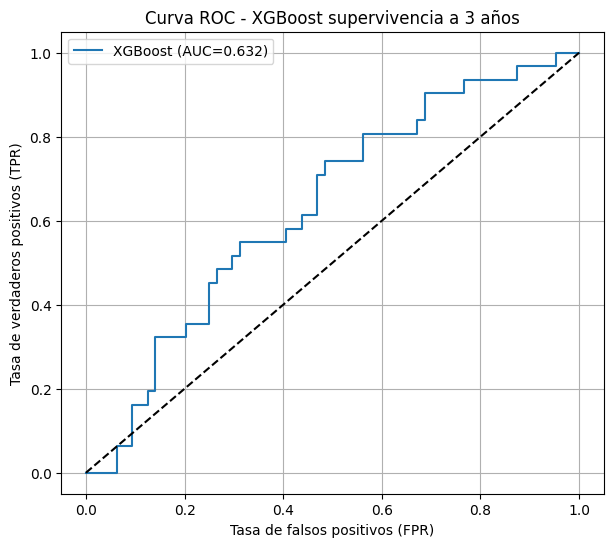

In [64]:
# Definir modelo XGBoost
xgb_clf = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.2,
    subsample=0.6,
    colsample_bytree=1.0,
    gamma=0.1,
    random_state=42
)

# Evaluar XGBoost
auc_xgb, y_test_xgb, y_proba_xgb = evaluar_modelo(xgb_clf, X, y, cv)
print(f"AUC ROC promedio XGBoost: {np.mean(auc_xgb):.4f} ± {np.std(auc_xgb):.4f}")

# Graficar curva ROC último fold
fpr, tpr, _ = roc_curve(y_test_xgb, y_proba_xgb)
plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f'XGBoost (AUC={auc_xgb[-1]:.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('Tasa de falsos positivos (FPR)')
plt.ylabel('Tasa de verdaderos positivos (TPR)')
plt.title('Curva ROC - XGBoost supervivencia a 3 años')
plt.legend()
plt.grid(True)
plt.show()


In [60]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 10],
    'subsample': [0.6, 0.8, 1.0],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

gb_clf = GradientBoostingClassifier(random_state=42)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(gb_clf, param_grid, cv=cv, scoring='roc_auc', n_jobs=-1)

grid_search.fit(X, y)

print("Mejores hiperparámetros Gradient Boosting:", grid_search.best_params_)
print("Mejor AUC ROC:", grid_search.best_score_)


Mejores hiperparámetros Gradient Boosting: {'learning_rate': 0.1, 'max_depth': 3, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100, 'subsample': 1.0}
Mejor AUC ROC: 0.6359285340415634


AUC ROC promedio Gradient Boosting: 0.6359 ± 0.0555


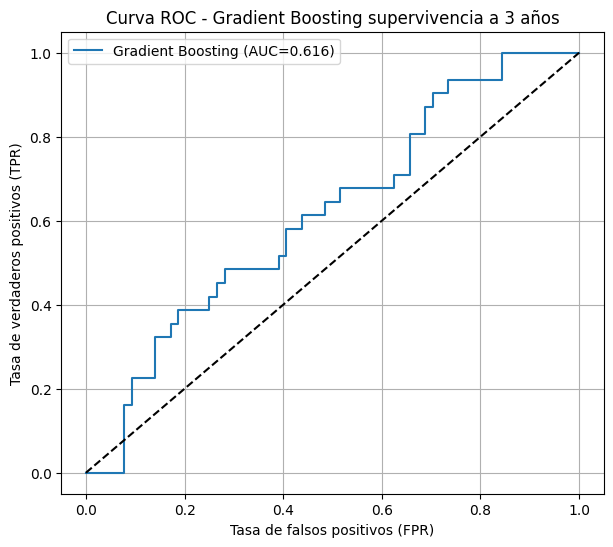

In [65]:
# Definir modelo Gradient Boosting
gb_clf = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    subsample=1.0,
    random_state=42,
    max_features= 'log2',
    min_samples_leaf=2,
    min_samples_split=5
)

# Evaluar Gradient Boosting
auc_gb, y_test_gb, y_proba_gb = evaluar_modelo(gb_clf, X, y, cv)
print(f"AUC ROC promedio Gradient Boosting: {np.mean(auc_gb):.4f} ± {np.std(auc_gb):.4f}")

# Graficar curva ROC último fold
fpr, tpr, _ = roc_curve(y_test_gb, y_proba_gb)
plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f'Gradient Boosting (AUC={auc_gb[-1]:.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('Tasa de falsos positivos (FPR)')
plt.ylabel('Tasa de verdaderos positivos (TPR)')
plt.title('Curva ROC - Gradient Boosting supervivencia a 3 años')
plt.legend()
plt.grid(True)
plt.show()